<a href="https://colab.research.google.com/github/true-cpu/DoAnKPDL/blob/main/DOANKPDL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import zipfile
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score

# Giải nén tệp tin
zip_path = 'archive.zip'
if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall('data')
    print("Giải nén thành công.")
else:
    print("Vui lòng đảm bảo tệp archive.zip đã được tải lên.")

Giải nén thành công.


In [2]:
# Giả sử dữ liệu nằm trong tệp csv sau khi giải nén
# Lưu ý: Thay đổi tên file 'social_media_data.csv' nếu tên thực tế khác
file_path = 'data/' + [f for f in os.listdir('data') if f.endswith('.csv')][0]
df = pd.read_csv(file_path)

# Kiểm tra sơ bộ
print("Thông tin dữ liệu:")
display(df.info())

# Xử lý giá trị thiếu
df = df.dropna()

# Loại bỏ các cột không phải số để tính toán tương quan
numeric_df = df.select_dtypes(include=[np.number])
display(numeric_df.head())

Thông tin dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   User ID         50000 non-null  int64 
 1   Username        50000 non-null  object
 2   Tweet           50000 non-null  object
 3   Retweet Count   50000 non-null  int64 
 4   Mention Count   50000 non-null  int64 
 5   Follower Count  50000 non-null  int64 
 6   Verified        50000 non-null  bool  
 7   Bot Label       50000 non-null  int64 
 8   Location        50000 non-null  object
 9   Created At      50000 non-null  object
 10  Hashtags        41659 non-null  object
dtypes: bool(1), int64(5), object(5)
memory usage: 3.9+ MB


None

,User ID,Retweet Count,Mention Count,Follower Count,Bot Label
1,289683,55,5,9617,0
2,779715,6,2,4363,0
3,696168,54,5,2242,1
4,704441,26,3,8438,1
5,570928,41,4,3792,1


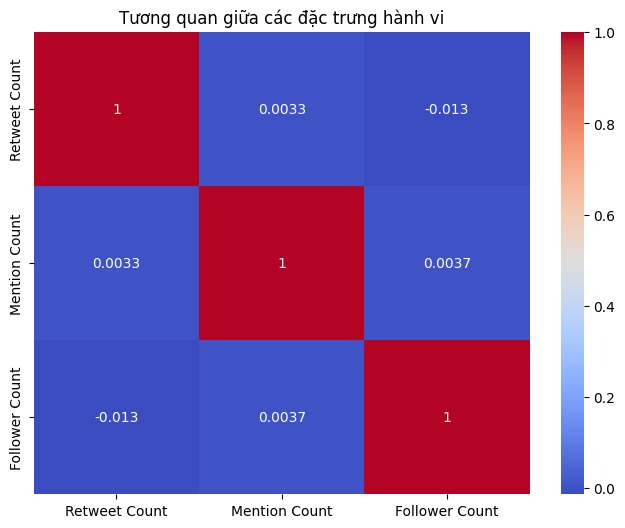

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# CHỈ giữ lại các đặc trưng hành vi thực tế, loại bỏ ID và Label (kết quả)
behavior_features = ['Retweet Count', 'Mention Count', 'Follower Count']
X = numeric_df[behavior_features]

# Hiển thị tương quan mới
corr_matrix = X.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Tương quan giữa các đặc trưng hành vi")
plt.show()

### 4. Chia bộ dữ liệu và Chuẩn hóa
Vì gom nhóm là học không giám sát, ta thường dùng toàn bộ tập dữ liệu hoặc chia để kiểm tra tính ổn định.

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Chia train/val để kiểm tra sự hội tụ
X_train, X_val = train_test_split(X_scaled, test_size=0.2, random_state=42)

### 5 & 6. Huấn luyện Model và Đánh giá (Loss/Accuracy thay bằng Elbow/Inertia)
Với gom nhóm, chúng ta sử dụng phương pháp 'Elbow' (Khuỷu tay) để tìm số cụm tối ưu.

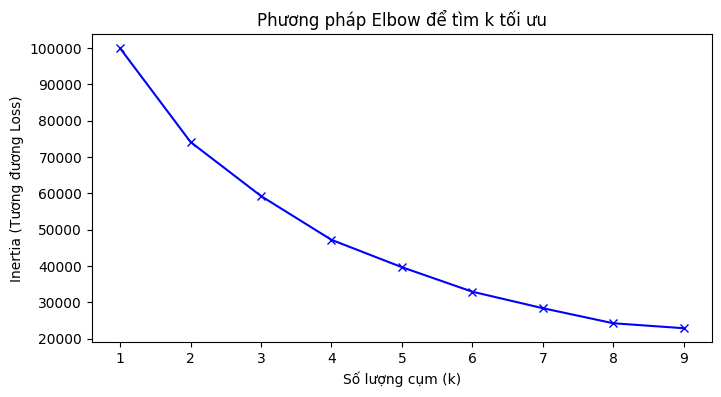

In [5]:
inertia = []
K = range(1, 10)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_train)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K, inertia, 'bx-')
plt.xlabel('Số lượng cụm (k)')
plt.ylabel('Inertia (Tương đương Loss)')
plt.title('Phương pháp Elbow để tìm k tối ưu')
plt.show()

### 7. Kết luận
Dưới đây là diễn giải kết quả cho người không chuyên.

In [6]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import plotly.express as px

# 1. Thực hiện phân cụm DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=50)
clusters = dbscan.fit_predict(X_scaled)
df['Cluster_ID'] = clusters

# 2. Đặt lại tên nhóm trực quan hơn dựa trên Mention Count
def rename_behavior(row_id):
    if row_id == -1: return "Hành vi đơn lẻ (Nhiễu)"
    # Ánh xạ ID sang tên dựa trên giá trị trung bình đã quan sát
    mapping = {
        0: "Nhóm Tương tác tối đa (5 Mentions)",
        1: "Nhóm Tương tác trung bình (2 Mentions)",
        2: "Nhóm Tương tác cao (3 Mentions)",
        3: "Nhóm Tương tác khá (4 Mentions)",
        4: "Nhóm Hoạt động thầm lặng (0 Mention)",
        5: "Nhóm Tương tác thấp (1 Mention)"
    }
    return mapping.get(row_id, f"Nhóm hành vi {row_id}")

df['Ten_Nhom'] = df['Cluster_ID'].apply(rename_behavior)

# 3. Đánh giá Model
sil_score = silhouette_score(X_scaled, clusters, sample_size=10000)
print(f"--- ĐÁNH GIÁ MODEL ---")
print(f"Silhouette Score: {sil_score:.4f}\n")

# 4. Vẽ biểu đồ 3D
df_sample = df.sample(n=2000, random_state=42)
fig = px.scatter_3d(
    df_sample,
    x='Retweet Count',
    y='Mention Count',
    z='Follower Count',
    color='Ten_Nhom',
    title="Phân tích định danh nhóm hành vi (3D) - Tên nhóm chuẩn hóa",
    labels={'Ten_Nhom': 'Loại hành vi'},
    opacity=0.7,
    color_discrete_sequence=px.colors.qualitative.Prism
)
fig.show()

# Hiển thị bảng thống kê
display(df.groupby('Ten_Nhom')[behavior_features + ['Bot Label']].mean(numeric_only=True))

--- ĐÁNH GIÁ MODEL ---
Silhouette Score: 0.0604



,Retweet Count,Mention Count,Follower Count,Bot Label
Ten_Nhom,,,,
Nhóm Hoạt động thầm lặng (0 Mention),50.003355,0.0,4945.235594,0.503428
Nhóm Tương tác cao (3 Mentions),49.843194,3.0,5052.461673,0.505538
Nhóm Tương tác khá (4 Mentions),50.237121,4.0,4948.243274,0.508014
Nhóm Tương tác thấp (1 Mention),49.881703,1.0,4985.482343,0.504723
Nhóm Tương tác trung bình (2 Mentions),49.602343,2.0,5010.407513,0.494072
Nhóm Tương tác tối đa (5 Mentions),50.134191,5.0,5003.350396,0.485860


### 8. Biểu đồ Đánh giá Mô hình Chuyên sâu
Phần này giúp chúng ta đánh giá mô hình không chỉ qua con số mà qua hình ảnh trực quan về sự phân tách các nhóm.

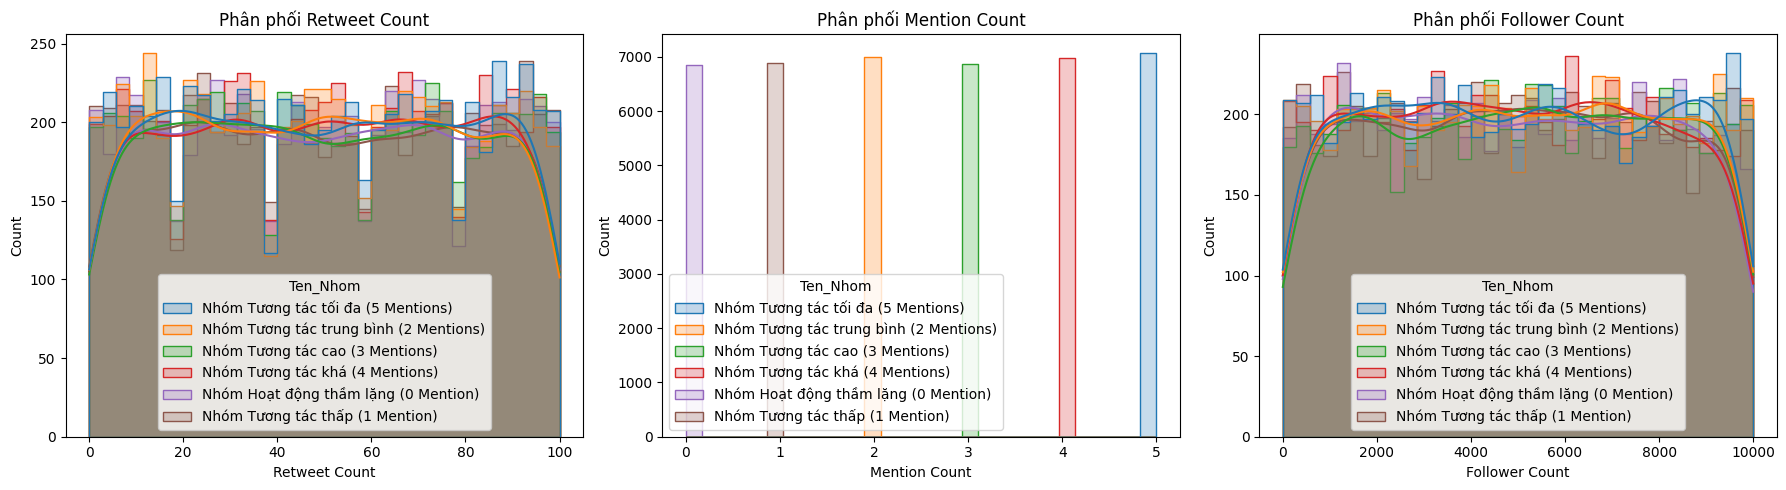

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

# Tắt cảnh báo về variance bằng 0 để biểu đồ sạch sẽ hơn
warnings.filterwarnings('ignore', category=UserWarning)

# 1. Biểu đồ phân phối hành vi giữa các nhóm (Histogram + KDE)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, feature in enumerate(behavior_features):
    # Sử dụng histplot thay vì kdeplot để xử lý trường hợp variance = 0
    sns.histplot(data=df, x=feature, hue='Ten_Nhom', kde=True, ax=axes[i], element="step", palette='tab10')
    axes[i].set_title(f'Phân phối {feature}')

plt.tight_layout()
plt.show()

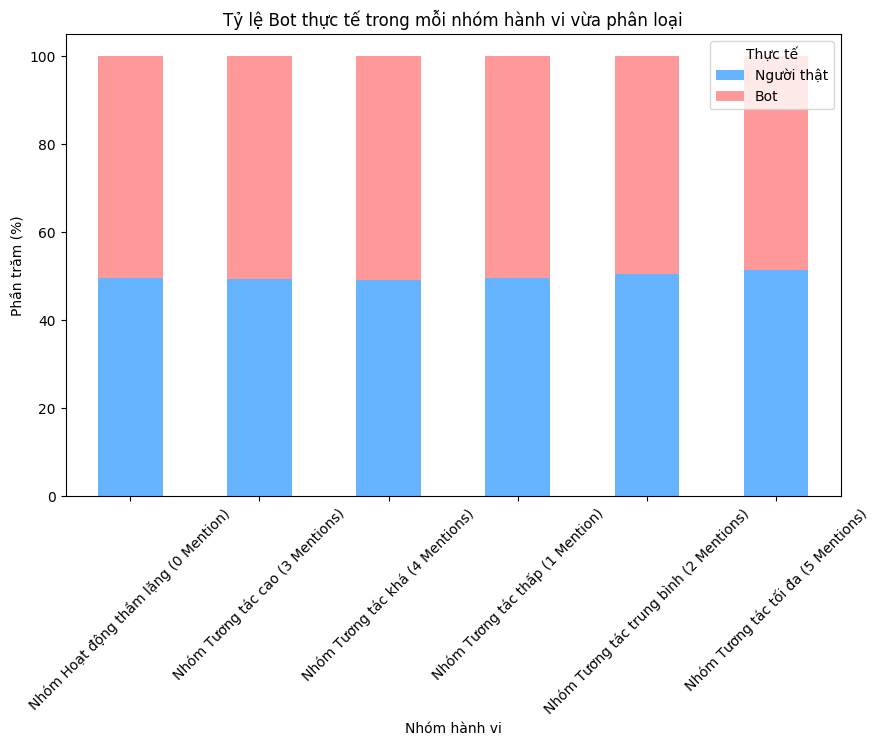

KẾT LUẬN ĐÁNH GIÁ:
- Nếu một nhóm có cột màu đỏ (Bot) chiếm đa số, đó là nhóm xác định đúng đối tượng bất thường.
- Nếu các cột đều có tỷ lệ 50/50, điều này xác nhận lại Silhouette Score thấp: hành vi Bot và Người trong bộ dữ liệu này cực kỳ giống nhau.


In [8]:
# 2. Đánh giá mức độ chính xác dựa trên nhãn thực tế (Bot Label)
# Vì đây là phân cụm không giám sát, ta kiểm tra xem các cụm tìm được có khớp với thực tế không
ct = pd.crosstab(df['Ten_Nhom'], df['Bot Label'], normalize='index') * 100

ct.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#66b3ff','#ff9999'])
plt.title('Tỷ lệ Bot thực tế trong mỗi nhóm hành vi vừa phân loại')
plt.ylabel('Phần trăm (%)')
plt.xlabel('Nhóm hành vi')
plt.legend(title='Thực tế', labels=['Người thật', 'Bot'])
plt.xticks(rotation=45)
plt.show()

print("KẾT LUẬN ĐÁNH GIÁ:")
print("- Nếu một nhóm có cột màu đỏ (Bot) chiếm đa số, đó là nhóm xác định đúng đối tượng bất thường.")
print("- Nếu các cột đều có tỷ lệ 50/50, điều này xác nhận lại Silhouette Score thấp: hành vi Bot và Người trong bộ dữ liệu này cực kỳ giống nhau.")